In [1]:
import numpy as np
import pandas as pd
import math
from uncertainties import unumpy as unp
from uncertainties import ufloat as uf
import numpy as np
import uncertainties.umath as umath
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
raw = pd.read_csv("Exp_C_Heat_of_Fusion.csv")

print(raw)

    Time (s)  Resistance (k Ohms)    Temp (K)
0          0                 9.31  299.936629
1         30                 9.31  299.936629
2         60                 9.31  299.936629
3         90                 9.31  299.936629
4        120                 9.31  299.936629
5        150                 9.31  299.936629
6        180                 9.31  299.936629
7        210                15.33  287.858998
8        240                17.43  284.876310
9        270                18.72  283.238786
10       300                19.34  282.496486
11       330                19.63  282.158443
12       360                19.76  282.008731
13       390                19.80  281.962889
14       420                19.77  281.997260
15       450                19.70  282.077690
16       480                19.63  282.158443
17       510                19.56  282.239522
18       540                19.50  282.309278
19       570                19.44  282.379278
20       600                19.38 

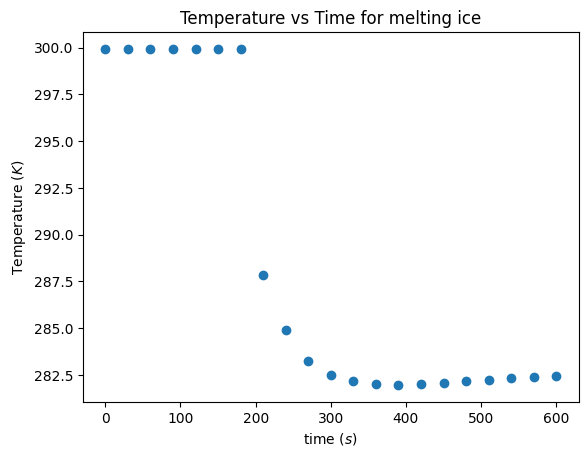

In [3]:
time = raw["Time (s)"]
Temp = raw["Temp (K)"]

plt.scatter(time, Temp)

plt.xlabel(r"time ($s$)")
plt.ylabel(r"Temperature ($K$)")
plt.title("Temperature vs Time for melting ice")

plt.show()


In [19]:
%%latex

$$L_f = \frac{(m_w \cdot c_w + m_{c+s} \cdot c_{c+s})(T_{iw} - T_f) - m_l \cdot c_w (T_f - T_{ii})}{m_I}$$

<IPython.core.display.Latex object>

In [16]:
mass_cup = uf(102.75, 0.01)/1000 #kg
mass_cup_water = uf(415.29,0.01)/1000 #kg
mass_with_ice = uf(453.13, 0.01)/1000 #kg
mass_water = mass_cup_water - mass_cup
mass_ice = mass_with_ice - mass_cup_water
init_cup_temp = uf(17.32, 0.05)+273.15

specific_heat_water = 4184 #J/Kg K
specific_heat_cup = 897 # J/Kg K

initial_temp = Temp[0]
lowest_temp = Temp.min()
#print(f"Lowest Temperature Achieved: {lowest_temp}")


L = mass_water*specific_heat_water + mass_cup*specific_heat_cup

L *= initial_temp - lowest_temp

L -= mass_ice*specific_heat_water*(lowest_temp - 237.15)

L/= (mass_ice)

print(L)


(4.7741+/-0.0026)e+05
